<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab08_Imbalanced_Data%20(Self-practice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8 — When the Thing You Care About Is 4% of Your Data

**Machine Learning (3 credits, 2-2-5) · Week 8 · School of Information Technology**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Evaluate a classifier honestly under class imbalance — 2. Apply and compare the three levers: threshold, class weights, SMOTE — 3. Recognise and prevent resampling leakage — 4. Build a reusable evaluation function and use it to compare models on equal terms|
| **Dataset** | WSN intrusion traffic (synthetic, built in this notebook) — 4,000 nodes, **3.7% attacks** |
| **Grading** | Exercises 1–6 + AI-usage disclosure · self-checks give instant feedback |

> **The deliverable that outlives this lab.** In Part 2 you write one `evaluate()` function. Every later section calls it, and you should carry it into M2 and M3 — most projects in this course have imbalanced targets, and a single trustworthy evaluation function is worth more than any individual model.

⚠️ **First:** File → Save a copy in Drive, rename to `Lab8_<your_student_id>`.

---
## Setup

Everything is generated in memory — nothing to download. Note the extra import: `imbalanced-learn` ships its **own** `Pipeline`, and Part 5 explains why that matters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score,
                             balanced_accuracy_score, precision_recall_curve)

from imblearn.pipeline import Pipeline as ImbPipeline     # <-- NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
print("setup complete ✔")

setup complete ✔


### Build the network traffic

4,000 sensor nodes. A small number are compromised. Two columns have missing readings, and `node_type` is categorical — so the preprocessing you have built since Week 2 still applies.

In [2]:
rng = np.random.default_rng(2026)
n = 4000

node_type = rng.choice(["leaf", "relay", "sink"], n, p=[0.66, 0.28, 0.06])
hop       = np.where(node_type == "sink", 1,
            np.where(node_type == "relay", rng.integers(1, 5, n), rng.integers(2, 9, n))).astype(float)
neighbour = np.clip(rng.normal(np.where(node_type == "sink", 12,
                    np.where(node_type == "relay", 7, 4)), 2.2, n), 0, None).round()
signal    = rng.normal(-62, 9, n) - 1.6*hop
battery   = rng.normal(3100, 240, n) - 16*hop
packet    = np.abs(rng.normal(300, 130, n))

# a compromised node is driven by several features at once, with heavy noise
_z = (0.42*(neighbour-6) - 0.30*(hop-4) + 0.055*(signal+62) + 0.0035*(packet-300)
      + 0.9*(node_type == "relay") - 4.6 + rng.normal(0, 1.6, n))
attack  = (_z > 0).astype(int)
packet  = packet + attack*rng.normal(40, 90, n)
battery = battery - attack*rng.normal(20, 70, n)

df = pd.DataFrame({"packet_rate": packet.round(1), "battery_mv": battery.round(0),
                   "hop_count": hop.astype(int), "neighbour_count": neighbour.astype(int),
                   "signal_dbm": signal.round(1), "node_type": node_type, "attack": attack})
for col, frac in [("battery_mv", 0.04), ("signal_dbm", 0.03)]:
    df.loc[rng.choice(n, int(frac*n), replace=False), col] = np.nan

NUM = ["packet_rate", "battery_mv", "hop_count", "neighbour_count", "signal_dbm"]
CAT = ["node_type"]
X, y = df.drop(columns="attack"), df["attack"]

print(f"{len(df)} nodes | {int(y.sum())} attacks ({y.mean():.2%}) | "
      f"{int(df.isna().sum().sum())} missing values")
print(df.head(3).to_string(index=False))

4000 nodes | 148 attacks (3.70%) | 280 missing values
 packet_rate  battery_mv  hop_count  neighbour_count  signal_dbm node_type  attack
       289.3      3060.0          8                1       -69.6      leaf       0
       459.4      3016.0          5                6       -80.4      leaf       0
       519.1      2648.0          5                1       -58.4      leaf       0


---
## Part 1 · The illusion

Split, build the usual preprocessing, fit a perfectly ordinary model, and look at how well it did.

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

PRE = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

plain = Pipeline([("pre", PRE), ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
pred  = plain.predict(X_te)

print(f"test set: {len(y_te)} nodes, {int(y_te.sum())} of them attacks\n")
print(f"  accuracy                 {accuracy_score(y_te, pred):.4f}   <- looks excellent")
print(f"  majority-class baseline  {1 - y_te.mean():.4f}   <- predicting 'normal' for everything")
print(f"  improvement over doing nothing: {accuracy_score(y_te, pred) - (1 - y_te.mean()):+.4f}")

test set: 1000 nodes, 37 of them attacks

  accuracy                 0.9700   <- looks excellent
  majority-class baseline  0.9630   <- predicting 'normal' for everything
  improvement over doing nothing: +0.0070


In [4]:
cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
print("confusion matrix  [[TN FP], [FN TP]]")
print(cm, "\n")
print(f"  attacks caught  (TP): {tp}")
print(f"  attacks MISSED  (FN): {fn}      <- the number that matters")
print(f"  false alarms    (FP): {fp}")
print(f"\n  recall    {recall_score(y_te, pred):.4f}   of the real attacks, this share was found")
print(f"  precision {precision_score(y_te, pred):.4f}   of the flagged nodes, this share were real")

confusion matrix  [[TN FP], [FN TP]]
[[961   2]
 [ 28   9]] 

  attacks caught  (TP): 9
  attacks MISSED  (FN): 28      <- the number that matters
  false alarms    (FP): 2

  recall    0.2432   of the real attacks, this share was found
  precision 0.8182   of the flagged nodes, this share were real


**Read those two blocks together.** Accuracy 0.970 against a baseline of 0.963 — seven thousandths of improvement for all that work. Precision is a respectable 0.818, which sounds encouraging until you notice *why*: the model flagged only 11 nodes out of 1,000, and was right about 9 of them. Being cautious is easy to be precise about.

**Recall is 0.243. Twenty-eight of the thirty-seven attacks walked straight past.**

This model would be deployed by a team that reported accuracy alone, and it would miss three intrusions in four.

---
## Part 2 · 🔧 A standardised evaluation function

Every comparison from here on must be on equal terms. Rather than retyping metrics, write the function once.

In [5]:
def evaluate(name, model, X_test=X_te, y_test=y_te, show=True):
    """Fit-agnostic evaluation. Returns a dict so results can be tabulated."""
    p  = model.predict(X_test)
    cm = confusion_matrix(y_test, p)
    tn, fp, fn, tp = cm.ravel()
    row = {
        "model":      name,
        "accuracy":   accuracy_score(y_test, p),
        "precision":  precision_score(y_test, p, zero_division=0),
        "recall":     recall_score(y_test, p),
        "macro_F1":   f1_score(y_test, p, average="macro"),
        "bal_acc":    balanced_accuracy_score(y_test, p),
        "missed":     int(fn),
        "false_alarms": int(fp),
    }
    if show:
        print(f"{name:26s} recall {row['recall']:.3f} | precision {row['precision']:.3f} | "
              f"macro-F1 {row['macro_F1']:.3f} | missed {fn:2d} | false alarms {fp:3d}")
    return row

results = [evaluate("plain LogisticRegression", plain)]

plain LogisticRegression   recall 0.243 | precision 0.818 | macro-F1 0.680 | missed 28 | false alarms   2


Notice what the function reports and what it does **not**. Accuracy is recorded but never printed, because under imbalance it is the number most likely to mislead a reader. `missed` and `false_alarms` are raw counts, because "28 intrusions undetected" lands differently from "recall 0.243" when you write it in a report.

---
## Part 3 · Lever 1 — move the threshold

The cheapest intervention of all. Nothing is retrained; we simply stop insisting on 0.5.

In [6]:
prob = plain.predict_proba(X_te)[:, 1]

print("threshold   recall  precision  flagged   missed")
for t in [0.50, 0.30, 0.20, 0.10, 0.05, 0.03]:
    pt = (prob >= t).astype(int)
    print(f"   {t:.2f}      {recall_score(y_te, pt):.3f}     {precision_score(y_te, pt, zero_division=0):.3f}"
          f"      {int(pt.sum()):4d}     {int(((pt == 0) & (y_te == 1)).sum()):3d}")

threshold   recall  precision  flagged   missed
   0.50      0.243     0.818        11      28
   0.30      0.486     0.545        33      19
   0.20      0.649     0.407        59      13
   0.10      0.757     0.275       102       9
   0.05      0.919     0.233       146       3
   0.03      1.000     0.188       197       0


**The same model, already trained, spans recall 0.243 to 1.000.** At a threshold of 0.03 it catches every single attack — at the cost of flagging 197 nodes to find 37, so a technician investigates five false alarms for each real one.

Nothing about the model changed. Only the line at which a probability becomes a decision, and that line is a business decision you are entitled to make.

---
## Part 4 · Levers 2 and 3 — class weights and SMOTE

In [7]:
weighted = Pipeline([("pre", PRE),
                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]).fit(X_tr, y_tr)

smote_pipe = ImbPipeline([("pre", PRE),
                          ("smote", SMOTE(random_state=SEED)),
                          ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)

results.append(evaluate("class_weight='balanced'", weighted))
results.append(evaluate("SMOTE", smote_pipe))

print("\n" + pd.DataFrame(results)[["model","recall","precision","macro_F1","missed","false_alarms"]]
      .round(3).to_string(index=False))

class_weight='balanced'    recall 0.919 | precision 0.202 | macro-F1 0.628 | missed  3 | false alarms 134
SMOTE                      recall 0.919 | precision 0.209 | macro-F1 0.633 | missed  3 | false alarms 129

                   model  recall  precision  macro_F1  missed  false_alarms
plain LogisticRegression   0.243      0.818     0.680      28             2
 class_weight='balanced'   0.919      0.202     0.628       3           134
                   SMOTE   0.919      0.209     0.633       3           129


**Two observations worth pausing on.**

First, **class weights and SMOTE land in almost the same place** — recall 0.919 each, precision 0.202 and 0.209. One of them is a keyword; the other manufactures roughly 2,700 synthetic rows. When they perform equally, prefer the one that invents nothing.

Second, and more importantly: look at the **macro-F1** column. It went *down* — 0.680 for the plain model, 0.628 and 0.633 after intervention. Yet recall went from 0.243 to 0.919, and missed attacks fell from 28 to 3.

Resampling did not improve the model. It **moved it along the precision–recall trade-off**. Whether that is progress depends entirely on what a missed intrusion costs relative to a false alarm — a question no metric can answer for you.

---
## Part 5 · ⚠️ The leak

The most consequential mistake in this entire lab. We will commit it deliberately, measure it, and then fix it.

In [8]:
cv = StratifiedKFold(5, shuffle=True, random_state=1)

# --- WRONG: resample the whole dataset, then cross-validate ---
X_prepared = PRE.fit_transform(X)
X_res, y_res = SMOTE(random_state=SEED).fit_resample(X_prepared, y)
leaked = cross_val_score(LogisticRegression(max_iter=2000), X_res, y_res, cv=cv, scoring="f1")

# --- RIGHT: resample inside the pipeline, so it happens after each fold is cut ---
honest = cross_val_score(
    ImbPipeline([("pre", PRE), ("smote", SMOTE(random_state=SEED)),
                 ("clf", LogisticRegression(max_iter=2000))]),
    X_tr, y_tr, cv=cv, scoring="f1")

print(f"SMOTE before the split (WRONG) : F1 {leaked.mean():.4f} +/- {leaked.std():.4f}")
print(f"SMOTE inside the pipeline      : F1 {honest.mean():.4f} +/- {honest.std():.4f}")
print(f"\nthe leak is worth {leaked.mean() - honest.mean():+.4f} F1 — a model {leaked.mean()/honest.mean():.1f}x better than the one you have")

SMOTE before the split (WRONG) : F1 0.8957 +/- 0.0111
SMOTE inside the pipeline      : F1 0.2903 +/- 0.0238

the leak is worth +0.6054 F1 — a model 3.1x better than the one you have


**0.896 against 0.290.** A team that resampled before splitting would report a model three times better than the one they actually built — and would have no idea why it collapsed on deployment.

**Why it happens:** SMOTE creates each synthetic point by interpolating between real minority points. Resample first, and a synthetic row built from a *training* point can land in the *validation* fold. The model is then scored on near-copies of things it trained on.

**The fix is structural, not a matter of care:** put the resampler inside an `ImbPipeline`, and cross-validation cuts the folds *before* SMOTE ever runs. The resampler is also applied only during `.fit()` — your test data is never resampled, which is exactly right.

---
## Part 6 · Would more data help?

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params

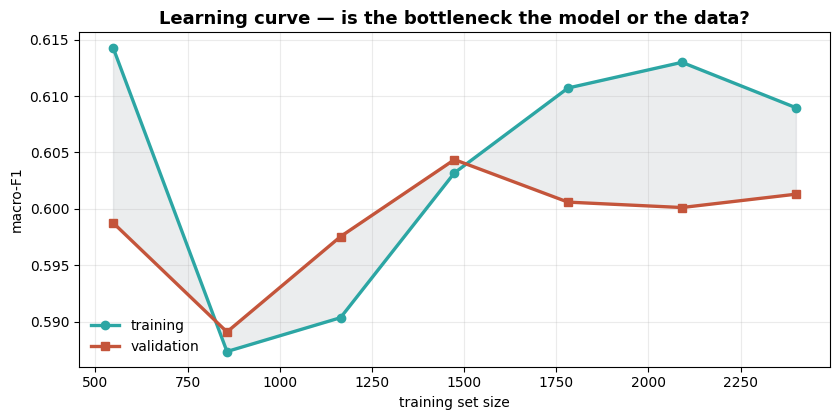

final gap between the curves: +0.0077


In [9]:
sizes, tr_scores, va_scores = learning_curve(
    ImbPipeline([("pre", PRE), ("smote", SMOTE(random_state=SEED)),
                 ("clf", LogisticRegression(max_iter=2000))]),
    X_tr, y_tr, cv=cv, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=SEED)

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(sizes, tr_scores.mean(1), marker="o", lw=2.4, color="#2CA6A4", label="training")
ax.plot(sizes, va_scores.mean(1), marker="s", lw=2.4, color="#C4553B", label="validation")
ax.fill_between(sizes, va_scores.mean(1), tr_scores.mean(1), color="#5F6B76", alpha=.12)
ax.set_xlabel("training set size"); ax.set_ylabel("macro-F1")
ax.set_title("Learning curve — is the bottleneck the model or the data?",
             fontsize=13, fontweight="bold")
ax.legend(frameon=False); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

print(f"final gap between the curves: {tr_scores.mean(1)[-1] - va_scores.mean(1)[-1]:+.4f}")

Read the gap. If the two curves have already met, collecting more nodes will not help — the limit is the model or the features. If a gap persists and the validation curve is still climbing, more data is a reasonable investment.

For an imbalanced problem there is a sharper version of the question: more data only helps if it brings **more minority examples**. Ten thousand additional normal nodes would change nothing here.

---
## Part 7 · The comparison table

Six models, one evaluation function, identical folds.

In [10]:
candidates = {
    "LogReg":          LogisticRegression(max_iter=2000),
    "LogReg + weight": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN (k=5)":       KNeighborsClassifier(),
    "Tree (d=5)":      DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "RandomForest":    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "SVM (rbf)":       SVC(random_state=SEED),
}

rows = []
for name, clf in candidates.items():
    pipe = Pipeline([("pre", PRE), ("clf", clf)])
    mf1 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1_macro")
    rec = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="recall")
    rows.append({"model": name,
                 "CV macro-F1": f"{mf1.mean():.3f} ± {mf1.std():.3f}",
                 "CV recall":   f"{rec.mean():.3f}",
                 "_sort": mf1.mean()})

table = pd.DataFrame(rows).sort_values("_sort", ascending=False).drop(columns="_sort")
print(table.to_string(index=False))

          model   CV macro-F1 CV recall
         LogReg 0.611 ± 0.055     0.154
LogReg + weight 0.597 ± 0.020     0.856
     Tree (d=5) 0.592 ± 0.061     0.154
   RandomForest 0.562 ± 0.053     0.100
      KNN (k=5) 0.546 ± 0.054     0.082
      SVM (rbf) 0.530 ± 0.036     0.045


**Now the uncomfortable part, and the point of the whole lab.**

Rank by macro-F1 and plain `LogReg` comes first at about 0.611. Rank by recall and it is nearly *last*, at 0.154 — it finds one attack in seven. The model that wins the summary metric is the one you would least want guarding a network.

`LogReg + weight` sits slightly lower on macro-F1 (~0.597) with recall around 0.856.

**A single number cannot make this decision.** Choose by writing down what an error costs, then read the column that measures it. That sentence belongs in your project report, and it is the difference between reporting a model and defending one.

---
---
# 🏋️ Exercises

Replace each `...`, run every ✅ self-check, complete the disclosure.

### Exercise 1 — What accuracy hides
Using `y_te` and the plain model's `pred`:
- **`baseline_acc`** — accuracy of always predicting "normal"
- **`gain`** — how much the model beats that baseline
- **`missed_attacks`** — how many real attacks it failed to flag

In [ ]:
baseline_acc = ...
gain = ...
missed_attacks = ...
print(f'baseline {baseline_acc:.4f} | gain {gain:+.4f} | missed {missed_attacks} of {int(y_te.sum())}')

In [ ]:
# ✅ Self-check — Exercise 1
assert abs(baseline_acc - (1 - y_te.mean())) < 1e-9, "baseline = the share of the majority class"
assert abs(gain - (accuracy_score(y_te, pred) - baseline_acc)) < 1e-9
assert missed_attacks == int(((pred == 0) & (y_te == 1)).sum()), "missed attacks are FALSE NEGATIVES"
print(f"Exercise 1 self-check passed ✔")
print(f"  the model beats 'predict normal always' by {gain:.4f} — and misses {missed_attacks} intrusions doing it.")

### Exercise 2 — Recall at a chosen threshold
Using `prob` (the plain model's probabilities) find the **highest** threshold from the list that still achieves **recall ≥ 0.85**:
- **`chosen_t`** — that threshold
- **`prec_at_t`**, **`flagged_at_t`** — precision, and how many nodes are flagged there

In [ ]:
cands = [0.50, 0.30, 0.20, 0.10, 0.05, 0.03]
ok = ...
chosen_t = ...
_p = (prob >= chosen_t).astype(int)
prec_at_t = ...
flagged_at_t = ...
print(f'threshold {chosen_t} | precision {prec_at_t:.3f} | flagged {flagged_at_t}')

In [ ]:
# ✅ Self-check — Exercise 2
assert recall_score(y_te, (prob >= chosen_t).astype(int)) >= 0.85, "recall must be at least 0.85"
_higher = [t for t in [0.50,0.30,0.20,0.10,0.05,0.03] if t > chosen_t]
assert all(recall_score(y_te, (prob >= t).astype(int)) < 0.85 for t in _higher), \
    "take the HIGHEST threshold that still reaches 0.85 recall"
print(f"Exercise 2 self-check passed ✔")
print(f"  at threshold {chosen_t} you catch ≥85% of attacks, flagging {flagged_at_t} nodes at precision {prec_at_t:.3f}.")
print("  No retraining was involved — this was free.")

### Exercise 3 — What the intervention bought
Compare the plain model against the class-weighted one on the test set:
- **`recall_gain`** — increase in recall
- **`precision_loss`** — decrease in precision
- **`fewer_missed`** — how many more attacks are caught

In [ ]:
pw = weighted.predict(X_te)
recall_gain = ...
precision_loss = ...
fewer_missed = ...
print(f'recall {recall_gain:+.3f} | precision {-precision_loss:+.3f} | {fewer_missed} more attacks caught')

In [ ]:
# ✅ Self-check — Exercise 3
_pw = weighted.predict(X_te)
assert abs(recall_gain - (recall_score(y_te,_pw) - recall_score(y_te,pred))) < 1e-9
assert recall_gain > 0.5, "class weighting should raise recall substantially here"
assert precision_loss > 0, "and precision should fall — that is the trade"
print(f"Exercise 3 self-check passed ✔")
print(f"  +{recall_gain:.3f} recall, −{precision_loss:.3f} precision, {fewer_missed} more intrusions caught.")
print("  Neither number is 'the answer'. The costs decide which you prefer.")

### Exercise 4 — Measure the leak
Quantify the resampling mistake using `leaked` and `honest` from Part 5:
- **`inflation`** — how much F1 the leak adds
- **`ratio`** — how many times better the leaked model appears
- **`leak_is_optimistic`** — `True` or `False`: does the leak make results look *better* than reality?

In [ ]:
inflation = ...
ratio = ...
leak_is_optimistic = ...
print(f'inflation {inflation:+.4f} | ratio {ratio:.2f}x | optimistic: {leak_is_optimistic}')

In [ ]:
# ✅ Self-check — Exercise 4
assert abs(inflation - (leaked.mean() - honest.mean())) < 1e-9
assert inflation > 0.3, "the leak should inflate F1 substantially on this dataset"
assert leak_is_optimistic is True, "leakage always flatters — that is what makes it dangerous"
print(f"Exercise 4 self-check passed ✔")
print(f"  the leak adds {inflation:.4f} F1 — the reported model looks {ratio:.1f}x better than it is.")
print("  It fails silently: no error, no warning, just a number that cannot survive deployment.")

### Exercise 5 — The metric disagrees with the mission
From the Part 7 comparison, establish which model wins on each criterion:
- **`best_macro_f1_model`** — the model name with the highest CV macro-F1
- **`best_recall_model`** — the model name with the highest CV recall
- **`same_model`** — `True` or `False`: are they the same?

In [ ]:
scores = {}
for name, clf in candidates.items():
    pipe = Pipeline([('pre', PRE), ('clf', clf)])
    scores[name] = (...,
                    ...)
best_macro_f1_model = ...
best_recall_model   = ...
same_model = ...
print(f'macro-F1 winner: {best_macro_f1_model}')
print(f'recall winner  : {best_recall_model}')
print(f'same model? {same_model}')

In [ ]:
# ✅ Self-check — Exercise 5
assert best_macro_f1_model in candidates and best_recall_model in candidates
assert same_model is False, "on this dataset the two criteria pick DIFFERENT models — that is the lesson"
print(f"Exercise 5 self-check passed ✔")
print(f"  macro-F1 says '{best_macro_f1_model}'. Recall says '{best_recall_model}'. They disagree.")
print("  A summary metric encodes a judgment about costs. Make that judgment deliberately.")

### Exercise 6 — Open-ended: one honest investigation
Pick **one**, carry it out properly (cross-validation on training data, mean ± spread), and write it up:

**(a)** **Does SMOTE beat class weighting?** Compare both on the *same* folds for a Random Forest, not just logistic regression. Report macro-F1 and recall. Does the answer change with the model?

**(b)** **Does the sampling ratio matter?** SMOTE's `sampling_strategy` need not be 1.0. Compare 0.1, 0.3, 0.5 and 1.0 — does full balancing actually help, or is partial better?

**(c)** **Cost-based threshold.** Assume a missed attack costs 200 units and a false alarm costs 1. Compute the total cost across thresholds from 0.01 to 0.9 for the plain model and find the cost-minimising threshold. How does it compare to 0.5?

Then write **3+ sentences**: what you did, what you found, and one caveat about what your evidence does *not* establish.

In [ ]:
# your investigation here — (a), (b) or (c)
...

*Your write-up (≥ 3 sentences): what you did · what you found · one caveat.*

✍️ ...

---
## 🧾 AI-usage disclosure (required)

> **AI tools used:** *e.g., "Claude — explained why ImbPipeline is needed instead of sklearn's Pipeline" — or — "None."*
>
> **Written and understood by:** *your name & student ID*
>
> I can explain every line of code in this notebook.

## 📤 Submitting

1. **Runtime → Restart session and run all** — clean run, every self-check *passed*.
2. Disclosure filled, notebook renamed `Lab8_<student_id>`.
3. **File → Download → .ipynb** → upload to the MS Team.

---
### 📌 Carry this forward
The `evaluate()` function from Part 2 is reusable — take it into **M2** and **M3**. Most projects in this course have imbalanced targets, and a report that shows per-class recall alongside a cost argument scores far better than one reporting accuracy.

*Dataset: synthetic WSN intrusion traffic, generated in this notebook. Modelled on the structure of the WSN-DS family; contains no real records.*